   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.9 MB/s eta 0:00:00
✅ Imports OK – 2026-05-05 05:37:46
🚀 Kafka Broker ready – topics: ['web-logs', 'transactions', 'customer-reviews', 'social-media-feed']

📊 Kafka Topic Message Counts:
   web-logs: 200
   transactions: 200
   customer-reviews: 200
   social-media-feed: 200

Sample web-log: {
  "offset": 0,
  "timestamp": "2026-05-05T05:37:46.384934",
  "data": {
    "user_id": "2a44b53d-8379-401d-83c2-6b0f1e93a416",
    "session_id": "b4eee2bd-2276-4b19-8e63-851593c52fb9",
    "action": "click",
    "page": "homepage",
    "timestamp": "2026-05-01T13:01:32.091226",
    "ip": "153.146.208.18",
    "device": "tablet",
    "search_query": null
  }
}

✅ Spark Streaming processed:
   Web Logs: 200 rows
   Transactions: 200 rows
   Reviews: 200 rows
   Social: 200 rows

🏞️  Data Lake ready (Bronze / Silver / Gold)
📥 Bronze zone:
   ✏️  [raw] web_logs_raw → 200 rows (~89.0 KB)
   ✏️  [raw] transactions_raw → 200 rows (~72.0 KB)
   ✏️ 

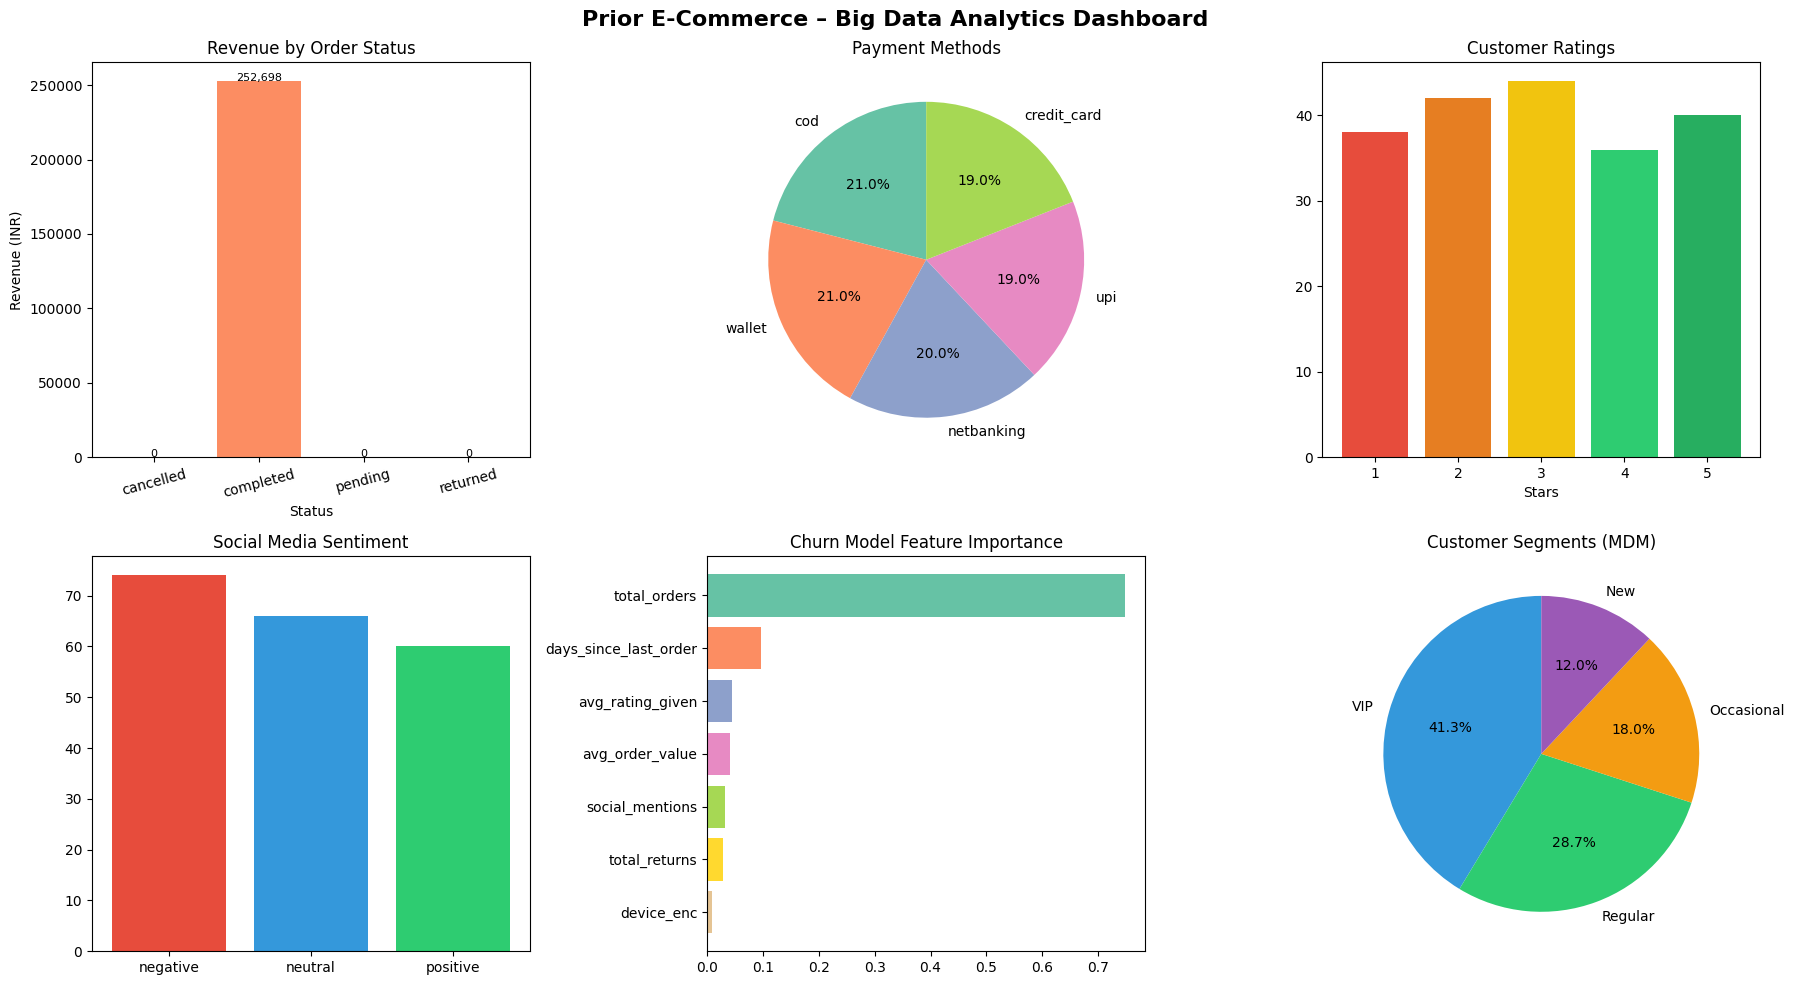


✅ Dashboard saved as prior_dashboard.png

🏁 All 9 pipeline components completed successfully!


In [1]:
# ============================================================
# BIG DATA ARCHITECTURE – Prior E-Commerce Case Study
# Run this in Google Colab cell by cell, or paste all at once
# ============================================================

# ── INSTALL ──────────────────────────────────────────────────
!pip install faker --quiet

# ── IMPORTS ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random, json
from datetime import datetime
from faker import Faker
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

fake = Faker()
np.random.seed(42)
random.seed(42)
print("✅ Imports OK –", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ════════════════════════════════════════════════════════════
# 1. DATA INGESTION – Apache Kafka Simulation
# ════════════════════════════════════════════════════════════
class KafkaSimulator:
    """Simulates Kafka topics (producer + consumer)."""
    def __init__(self):
        self.topics = {
            'web-logs': [], 'transactions': [],
            'customer-reviews': [], 'social-media-feed': []
        }
        print("🚀 Kafka Broker ready – topics:", list(self.topics))

    def produce(self, topic, msg):
        self.topics[topic].append({
            'offset': len(self.topics[topic]),
            'timestamp': datetime.now().isoformat(),
            'data': msg
        })

    def consume(self, topic, n=200):
        return self.topics[topic][:n]

    def stats(self):
        print("\n📊 Kafka Topic Message Counts:")
        for t, msgs in self.topics.items():
            print(f"   {t}: {len(msgs)}")


kafka = KafkaSimulator()

# Source 1 – Web Logs (2 TB/day, unstructured)
pages   = ['homepage','product_detail','search','cart','checkout','confirmation']
actions = ['click','search','page_view','add_to_cart','purchase']
for _ in range(200):
    kafka.produce('web-logs', {
        'user_id':      fake.uuid4(),
        'session_id':   fake.uuid4(),
        'action':       random.choice(actions),
        'page':         random.choice(pages),
        'timestamp':    fake.date_time_this_month().isoformat(),
        'ip':           fake.ipv4(),
        'device':       random.choice(['mobile','desktop','tablet']),
        'search_query': fake.word() if random.random() > 0.5 else None
    })

# Source 2 – Transactions (500 GB/day, structured)
statuses  = ['completed','pending','returned','cancelled']
pay_types = ['credit_card','upi','netbanking','wallet','cod']
for _ in range(200):
    kafka.produce('transactions', {
        'order_id':       fake.uuid4(),
        'customer_id':    fake.uuid4(),
        'amount':         round(random.uniform(99, 9999), 2),
        'currency':       'INR',
        'status':         random.choice(statuses),
        'payment_method': random.choice(pay_types),
        'timestamp':      fake.date_time_this_month().isoformat(),
        'items_count':    random.randint(1, 10)
    })

# Source 3 – Customer Reviews (200 GB/day, semi-structured)
for _ in range(200):
    kafka.produce('customer-reviews', {
        'review_id':   fake.uuid4(),
        'customer_id': fake.uuid4(),
        'product_id':  fake.uuid4(),
        'rating':      random.randint(1, 5),
        'review_text': fake.sentence(nb_words=20),
        'has_image':   random.choice([True, False]),
        'timestamp':   fake.date_time_this_month().isoformat()
    })

# Source 4 – Social Media Feed (100 GB/day, unstructured)
platforms  = ['twitter','facebook','instagram']
sentiments = ['positive','neutral','negative']
for _ in range(200):
    kafka.produce('social-media-feed', {
        'post_id':   fake.uuid4(),
        'platform':  random.choice(platforms),
        'text':      fake.sentence(nb_words=15),
        'likes':     random.randint(0, 5000),
        'shares':    random.randint(0, 500),
        'sentiment': random.choice(sentiments),
        'timestamp': fake.date_time_this_month().isoformat()
    })

kafka.stats()
print("\nSample web-log:", json.dumps(kafka.consume('web-logs', 1)[0], indent=2))


# ════════════════════════════════════════════════════════════
# 2. STREAM PROCESSING – Apache Spark Streaming
# ════════════════════════════════════════════════════════════
class SparkStreamingSimulator:
    def process_web_logs(self, msgs):
        df = pd.DataFrame([m['data'] for m in msgs])
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['hour']      = df['timestamp'].dt.hour
        df['is_mobile'] = df['device'] == 'mobile'
        return df

    def process_transactions(self, msgs):
        df = pd.DataFrame([m['data'] for m in msgs])
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['is_return'] = df['status'] == 'returned'
        df['revenue']   = df.apply(
            lambda r: r['amount'] if r['status'] == 'completed' else 0, axis=1)
        return df

    def process_reviews(self, msgs):
        return pd.DataFrame([m['data'] for m in msgs])

    def process_social(self, msgs):
        return pd.DataFrame([m['data'] for m in msgs])


spark = SparkStreamingSimulator()
web_logs_df     = spark.process_web_logs(kafka.consume('web-logs'))
transactions_df = spark.process_transactions(kafka.consume('transactions'))
reviews_df      = spark.process_reviews(kafka.consume('customer-reviews'))
social_df       = spark.process_social(kafka.consume('social-media-feed'))

print("\n✅ Spark Streaming processed:")
for name, df in [("Web Logs", web_logs_df), ("Transactions", transactions_df),
                 ("Reviews", reviews_df), ("Social", social_df)]:
    print(f"   {name}: {len(df)} rows")


# ════════════════════════════════════════════════════════════
# 3. DATA LAKE – Bronze / Silver / Gold
# ════════════════════════════════════════════════════════════
class DataLake:
    def __init__(self):
        self.zones = {'raw': {}, 'processed': {}, 'curated': {}}
        print("\n🏞️  Data Lake ready (Bronze / Silver / Gold)")

    def write(self, zone, table, df):
        self.zones[zone][table] = df
        kb = df.memory_usage(deep=True).sum() / 1024
        print(f"   ✏️  [{zone}] {table} → {len(df)} rows (~{kb:.1f} KB)")

    def read(self, zone, table):
        return self.zones[zone].get(table, pd.DataFrame())

    def ls(self):
        print("\n📂 Data Lake Contents:")
        for zone, tables in self.zones.items():
            print(f"  [{zone.upper()}]")
            for t, df in tables.items():
                print(f"    {t}: {len(df)} rows")


lake = DataLake()

# Bronze (raw)
print("📥 Bronze zone:")
lake.write('raw', 'web_logs_raw',     web_logs_df)
lake.write('raw', 'transactions_raw', transactions_df)
lake.write('raw', 'reviews_raw',      reviews_df)
lake.write('raw', 'social_raw',       social_df)

# Silver (cleaned)
print("\n🔄 Silver zone:")
clean_tx = transactions_df.dropna().copy()
clean_tx['amount'] = clean_tx['amount'].clip(lower=0)
lake.write('processed', 'transactions_clean', clean_tx)

clean_reviews = reviews_df.dropna(subset=['rating']).copy()
clean_reviews['rating'] = clean_reviews['rating'].astype(int)
lake.write('processed', 'reviews_clean', clean_reviews)

# Gold (aggregated)
print("\n✨ Gold zone:")
rev_summary = clean_tx.groupby('status')['revenue'].agg(['sum','count']).reset_index()
rev_summary.columns = ['status','total_revenue','order_count']
lake.write('curated', 'daily_revenue_summary', rev_summary)

rating_dist = clean_reviews.groupby('rating').size().reset_index(name='review_count')
lake.write('curated', 'rating_distribution', rating_dist)

lake.ls()


# ════════════════════════════════════════════════════════════
# 4. DATA WAREHOUSE – Apache Hive
# ════════════════════════════════════════════════════════════
class HiveWarehouse:
    def __init__(self, data_lake):
        self.lake   = data_lake
        self.tables = {}
        print("\n🐝 Hive Metastore initialized")

    def create_table(self, name, zone, source):
        df = self.lake.read(zone, source)
        self.tables[name] = df
        print(f"   CREATE TABLE {name} ← {zone}.{source} ({len(df)} rows)")

    def query(self, desc, df, group_col, agg_col, func='sum', n=5):
        print(f"\n🔍 HiveQL: {desc}")
        result = df.groupby(group_col)[agg_col].agg(func).reset_index()
        result.columns = [group_col, f'{func}_{agg_col}']
        result = result.sort_values(f'{func}_{agg_col}', ascending=False).head(n)
        print(result.to_string(index=False))
        return result


hive = HiveWarehouse(lake)
hive.create_table('fact_transactions', 'processed', 'transactions_clean')
hive.create_table('fact_reviews',      'processed', 'reviews_clean')

hive.query('SELECT status, SUM(revenue) GROUP BY status',
           clean_tx, 'status', 'revenue', 'sum')
hive.query('SELECT payment_method, COUNT(*) GROUP BY payment_method',
           clean_tx, 'payment_method', 'amount', 'count')
hive.query('SELECT rating, COUNT(*) GROUP BY rating',
           clean_reviews, 'rating', 'review_id', 'count')


# ════════════════════════════════════════════════════════════
# 5. MACHINE LEARNING – Spark MLlib (scikit-learn)
# ════════════════════════════════════════════════════════════
print("\n🤖 Spark MLlib – Customer Churn Prediction")
print("=" * 50)

N = 500
cust = pd.DataFrame({
    'customer_id':          [fake.uuid4() for _ in range(N)],
    'total_orders':         np.random.randint(1, 50, N),
    'avg_order_value':      np.random.uniform(200, 5000, N).round(2),
    'total_returns':        np.random.randint(0, 10, N),
    'avg_rating_given':     np.random.uniform(1, 5, N).round(1),
    'days_since_last_order':np.random.randint(1, 365, N),
    'social_mentions':      np.random.randint(0, 20, N),
    'preferred_device':     np.random.choice(['mobile','desktop','tablet'], N)
})
cust['churned'] = (
    (cust['days_since_last_order'] > 90) & (cust['total_orders'] < 5)
).astype(int)

print(f"Dataset: {N} customers | Churned: {cust['churned'].sum()} "
      f"({cust['churned'].mean()*100:.1f}%)")

le = LabelEncoder()
cust['device_enc'] = le.fit_transform(cust['preferred_device'])

features = ['total_orders','avg_order_value','total_returns',
            'avg_rating_given','days_since_last_order','social_mentions','device_enc']
X = cust[features]
y = cust['churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

fi = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
fi = fi.sort_values('importance', ascending=False)
print("Feature Importances:\n", fi.to_string(index=False))


# ════════════════════════════════════════════════════════════
# 6. SECURITY – Apache Ranger
# ════════════════════════════════════════════════════════════
class ApacheRanger:
    POLICIES = {
        'data_engineer':  {'zones': ['raw','processed','curated'], 'tables': ['*'], 'mask': []},
        'data_scientist': {'zones': ['processed','curated'],
                           'tables': ['fact_transactions','fact_reviews'], 'mask': ['customer_id','order_id']},
        'business_analyst': {'zones': ['curated'], 'tables': ['daily_revenue_summary'], 'mask': ['customer_id']},
        'external_vendor':  {'zones': [], 'tables': [], 'mask': ['*']},
    }

    def check(self, role, zone, table):
        p = self.POLICIES.get(role, {})
        if zone not in p.get('zones', []):
            return f"❌ DENIED  [{role}] → {zone}.{table}"
        if '*' not in p.get('tables', []) and table not in p.get('tables', []):
            return f"❌ DENIED  [{role}] → {zone}.{table}"
        return f"✅ ALLOWED [{role}] → {zone}.{table}"

    def mask(self, role, df):
        cols = self.POLICIES.get(role, {}).get('mask', [])
        out  = df.copy()
        for c in cols:
            if c in out.columns:
                out[c] = '****'
        return out


ranger = ApacheRanger()
print("\n🛡️  Apache Ranger – Access Control Audit")
tests = [
    ('data_engineer',    'raw',       'web_logs_raw'),
    ('data_scientist',   'processed', 'fact_transactions'),
    ('data_scientist',   'raw',       'web_logs_raw'),
    ('business_analyst', 'curated',   'daily_revenue_summary'),
    ('business_analyst', 'processed', 'fact_transactions'),
    ('external_vendor',  'curated',   'daily_revenue_summary'),
]
for role, zone, table in tests:
    print(" ", ranger.check(role, zone, table))

sample = clean_tx[['order_id','customer_id','amount','status']].head(3)
print("\nData Scientist masked view:")
print(ranger.mask('data_scientist', sample).to_string(index=False))


# ════════════════════════════════════════════════════════════
# 7. DATA GOVERNANCE – Apache Atlas
# ════════════════════════════════════════════════════════════
class ApacheAtlas:
    def __init__(self):
        self.catalog = {}
        self.lineage  = []

    def register(self, name, src, desc, owner, pii=[]):
        tag = 'PII' if pii else 'NON-PII'
        self.catalog[name] = {'src': src, 'desc': desc, 'owner': owner, 'tag': tag}
        print(f"   📋 {name} | {owner} | {tag}")

    def add_lineage(self, src, tgt, op):
        self.lineage.append((src, op, tgt))

    def show_lineage(self):
        print("\n🔗 Data Lineage:")
        for src, op, tgt in self.lineage:
            print(f"   [{src}] --({op})--> [{tgt}]")

    def search(self, kw):
        hits = {k: v for k, v in self.catalog.items() if kw.lower() in k.lower()}
        print(f"\n🔍 Search '{kw}': {len(hits)} result(s)")
        for k, v in hits.items():
            print(f"   {k}: {v['desc']}")


atlas = ApacheAtlas()
print("\n🗺️  Apache Atlas – Data Catalog")
atlas.register('web_logs_raw',      'Kafka:web-logs',    'Raw clickstream',         'eng-team',  pii=['user_id','ip'])
atlas.register('transactions_raw',  'Kafka:transactions','Raw order/payment events', 'eng-team',  pii=['customer_id'])
atlas.register('transactions_clean','Silver Zone',        'Cleaned transactions',    'eng-team',  pii=['customer_id'])
atlas.register('daily_revenue',     'Gold Zone',          'Revenue aggregation',     'analytics', pii=[])
atlas.register('churn_model',       'ML Pipeline',        'Churn RF model',          'data-sci',  pii=[])

atlas.add_lineage('Kafka:web-logs',          'raw/web_logs_raw',           'Kafka Consumer')
atlas.add_lineage('raw/web_logs_raw',        'processed/web_logs_clean',   'Spark Streaming')
atlas.add_lineage('Kafka:transactions',      'raw/transactions_raw',       'Kafka Consumer')
atlas.add_lineage('raw/transactions_raw',    'processed/transactions_clean','Spark + Validation')
atlas.add_lineage('processed/transactions_clean', 'curated/daily_revenue', 'Hive GROUP BY')
atlas.add_lineage('processed/transactions_clean', 'churn_model',           'Spark MLlib')
atlas.show_lineage()
atlas.search('transaction')


# ════════════════════════════════════════════════════════════
# 8. MASTER DATA MANAGEMENT (MDM) – Single Customer View
# ════════════════════════════════════════════════════════════
print("\n👤 MDM – Building Single Customer View")
print("=" * 45)

N2 = 300
crm = pd.DataFrame({
    'email': [fake.email()  for _ in range(N2)],
    'name':  [fake.name()   for _ in range(N2)],
    'phone': [fake.phone_number() for _ in range(N2)],
})
ecom = pd.DataFrame({
    'email':        crm['email'].sample(N2, replace=True).values,
    'city':         [fake.city() for _ in range(N2)],
    'total_orders': np.random.randint(1, 50, N2),
})

golden = pd.merge(crm, ecom, on='email', how='inner')
golden['golden_id'] = [fake.uuid4() for _ in range(len(golden))]
golden['segment']   = pd.cut(
    golden['total_orders'], bins=[0,5,15,30,100],
    labels=['New','Occasional','Regular','VIP']
)

print(f"CRM: {len(crm)} | ECOM: {len(ecom)} | Golden: {len(golden)}")
print("\nCustomer Segments:")
print(golden['segment'].value_counts().to_string())
print("\nSample golden record:")
print(golden[['golden_id','name','email','city','total_orders','segment']].head(3).to_string(index=False))

lake.write('curated', 'golden_customer_records', golden)


# ════════════════════════════════════════════════════════════
# 9. WORKFLOW ORCHESTRATION – Apache Airflow
# ════════════════════════════════════════════════════════════
class AirflowDAG:
    def __init__(self, dag_id, schedule):
        self.dag_id   = dag_id
        self.schedule = schedule
        self.tasks    = []
        print(f"\n🌬️  Airflow DAG: [{dag_id}]  Schedule: {schedule}")

    def task(self, tid, deps=None):
        self.tasks.append({'id': tid, 'deps': deps or [], 'status': 'pending'})

    def run(self):
        print(f"\n🚀 Running DAG [{self.dag_id}]…")
        completed = set()
        for t in self.tasks:
            blocked = [d for d in t['deps'] if d not in completed]
            if blocked:
                t['status'] = 'skipped'
                icon = '⏭️ '
            else:
                ok = random.random() > 0.05
                t['status'] = 'success' if ok else 'failed'
                icon = '✅' if ok else '❌'
                if ok:
                    completed.add(t['id'])
            dep_str = f"  ← {', '.join(t['deps'])}" if t['deps'] else ''
            print(f"   {icon} {t['id']:<42} [{t['status']}]{dep_str}")
        ok_n = sum(1 for t in self.tasks if t['status'] == 'success')
        print(f"\n   {ok_n}/{len(self.tasks)} tasks succeeded")


dag = AirflowDAG('prior_daily_pipeline', '@daily')
dag.task('kafka_ingest_web_logs')
dag.task('kafka_ingest_transactions')
dag.task('kafka_ingest_reviews')
dag.task('kafka_ingest_social')
dag.task('spark_process_web_logs',    ['kafka_ingest_web_logs'])
dag.task('spark_process_transactions',['kafka_ingest_transactions'])
dag.task('spark_process_reviews',     ['kafka_ingest_reviews'])
dag.task('spark_process_social',      ['kafka_ingest_social'])
dag.task('write_bronze_zone',         ['spark_process_web_logs','spark_process_transactions'])
dag.task('write_silver_zone',         ['write_bronze_zone'])
dag.task('hive_aggregate',            ['write_silver_zone'])
dag.task('mdm_golden_records',        ['write_silver_zone'])
dag.task('mlb_churn_model',           ['mdm_golden_records'])
dag.task('atlas_update_lineage',      ['hive_aggregate'])
dag.task('ranger_apply_policies',     ['atlas_update_lineage'])
dag.task('write_gold_zone',           ['hive_aggregate','mdm_golden_records'])
dag.task('notify_slack',              ['write_gold_zone'])
dag.run()


# ════════════════════════════════════════════════════════════
# FINAL – Analytics Dashboard
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Prior E-Commerce – Big Data Analytics Dashboard',
             fontsize=16, fontweight='bold')
pal = sns.color_palette('Set2')

# 1 Revenue by status
rev = clean_tx.groupby('status')['revenue'].sum().reset_index()
bars = axes[0,0].bar(rev['status'], rev['revenue'], color=pal)
axes[0,0].set_title('Revenue by Order Status')
axes[0,0].set_xlabel('Status'); axes[0,0].set_ylabel('Revenue (INR)')
axes[0,0].tick_params(axis='x', rotation=15)
for b, v in zip(bars, rev['revenue']):
    axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+50,
                   f'{v:,.0f}', ha='center', fontsize=8)

# 2 Payment method pie
pay = clean_tx['payment_method'].value_counts()
axes[0,1].pie(pay.values, labels=pay.index, autopct='%1.1f%%', colors=pal, startangle=90)
axes[0,1].set_title('Payment Methods')

# 3 Rating bar
ratings = clean_reviews['rating'].value_counts().sort_index()
axes[0,2].bar(ratings.index, ratings.values,
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[0,2].set_title('Customer Ratings')
axes[0,2].set_xlabel('Stars'); axes[0,2].set_xticks([1,2,3,4,5])

# 4 Social sentiment
sent = social_df['sentiment'].value_counts()
scol = {'positive':'#2ecc71','neutral':'#3498db','negative':'#e74c3c'}
axes[1,0].bar(sent.index, sent.values,
              color=[scol.get(s,'gray') for s in sent.index])
axes[1,0].set_title('Social Media Sentiment')

# 5 Feature importance
axes[1,1].barh(fi['feature'], fi['importance'], color=pal)
axes[1,1].set_title('Churn Model Feature Importance')
axes[1,1].invert_yaxis()

# 6 Customer segments
segs = golden['segment'].value_counts()
axes[1,2].pie(segs.values, labels=segs.index, autopct='%1.1f%%',
              colors=['#3498db','#2ecc71','#f39c12','#9b59b6'], startangle=90)
axes[1,2].set_title('Customer Segments (MDM)')

plt.tight_layout()
plt.savefig('prior_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved as prior_dashboard.png")
print("\n🏁 All 9 pipeline components completed successfully!")